# Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2026-07-01")
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
    df = df.loc[:, ~df.columns.duplicated()]

# Data exploration

In [ ]:
head = df.head(5)
info = df.info()
describe = df.describe()
null = df.isnull().sum()
print(null)

# Data cleaning and preprocessing

In [ ]:
# Ensure the time series is sorted and cast to a datetime index, then handle missing values.
df = df.sort_index()
df.index = pd.to_datetime(df.index)

missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts)

# Use row-based dropna to preserve the core time series if there are any empty rows.
df = df.dropna()
print(f"\nRows after dropna: {len(df)}")

# Data transformation using pandas

In [ ]:
# Create new analytical features from the raw price data.
df["Daily Change"] = df["Close"] - df["Open"]
df["Daily Pct Change"] = (df["Close"] - df["Open"]) / df["Open"] * 100
df["Daily Range"] = df["High"] - df["Low"]
df["Log Return"] = np.log(df["Close"] / df["Close"].shift(1))

# Aggregate at the monthly level to summarize performance.
monthly_close = df[["Close"]].resample("ME").last().squeeze()
avg_pct_change = df[["Daily Pct Change"]].resample("ME").mean().squeeze()
avg_daily_range = df[["Daily Range"]].resample("ME").mean().squeeze()

monthly_summary = pd.DataFrame(
    {
        "monthly_close": monthly_close,
        "avg_pct_change": avg_pct_change,
        "avg_daily_range": avg_daily_range,
    }
)
monthly_summary["monthly_return"] = monthly_summary["monthly_close"].pct_change() * 100

print("Sample engineered features:")
display(df[["Daily Change", "Daily Pct Change", "Daily Range", "Log Return"]].head())
print("\nMonthly summary sample:")
display(monthly_summary.tail(5))
print("Top 5 daily percent gain days in 2024:")
display(df.loc["2024"].nlargest(5, "Daily Pct Change")[['Close', 'Daily Pct Change']])

# Time series analysis

In [ ]:
# Compute rolling moving averages, monthly returns, and volatility.
df["MA_7"] = df["Close"].rolling(7, min_periods=1).mean()
df["MA_30"] = df["Close"].rolling(30, min_periods=1).mean()
df["Volatility_30d"] = df["Log Return"].rolling(30).std() * np.sqrt(252)

monthly_close = df["Close"].resample("ME").last()
monthly_returns = monthly_close.pct_change() * 100

print("Rolling averages and volatility sample:")
display(df[["Close", "MA_7", "MA_30", "Volatility_30d"]].tail())
print("\nMonthly returns sample:")
display(monthly_returns.tail())

# Data visualization

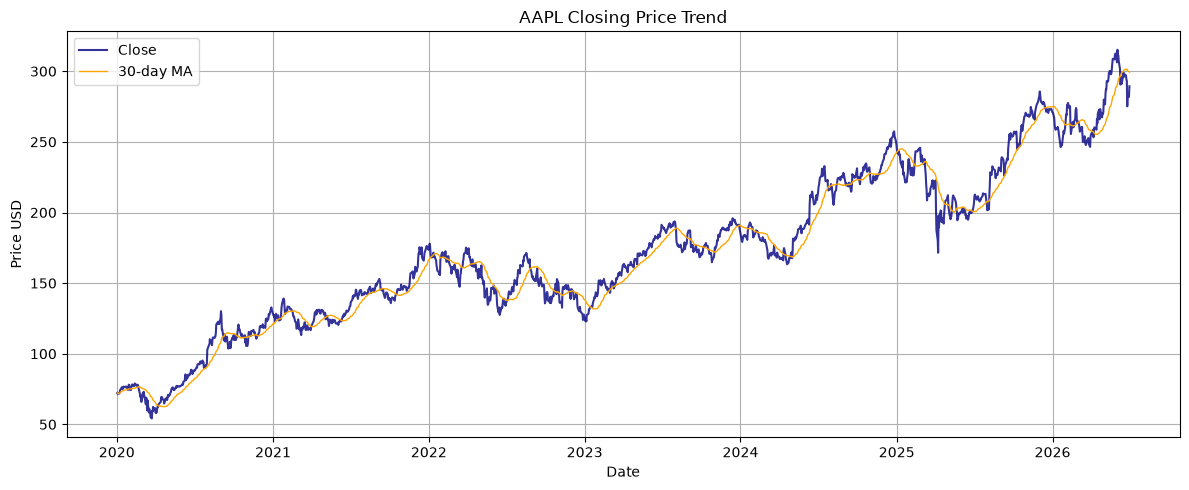

ValueError: 'y1' is not 1-dimensional

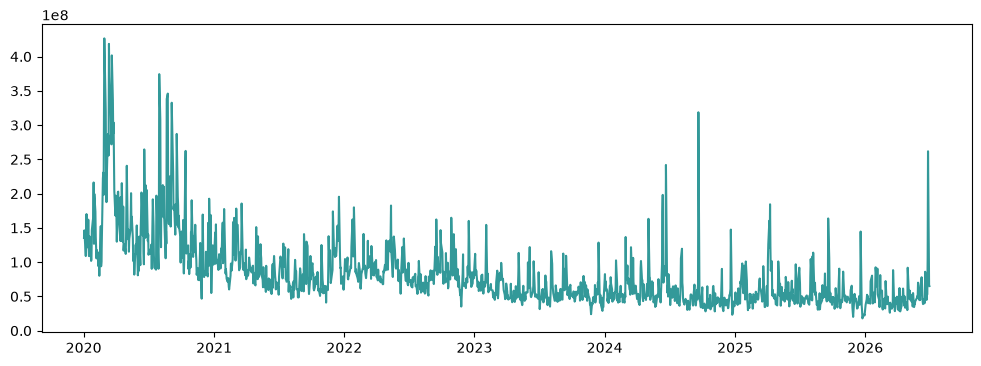

In [23]:
# Compute additional visualization features.
df["MA_20"] = df["Close"].rolling(20, min_periods=1).mean()
df["BB_std"] = df["Close"].rolling(20, min_periods=1).std()
df["BB_upper"] = df["MA_20"] + 2 * df["BB_std"]
df["BB_lower"] = df["MA_20"] - 2 * df["BB_std"]

daily_returns = df["Close"].pct_change() * 100

# 1) Stock Closing Price Trend
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close", color="navy", alpha=0.8)
plt.plot(df["MA_30"], label="30-day MA", color="orange", linewidth=1)
plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Trading Volume Trend
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Volume"], color="teal", alpha=0.8)
plt.fill_between(df.index, df["Volume"], color="teal", alpha=0.2)
plt.title("AAPL Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# 3) Moving Average Channels (Bollinger-style)
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close", color="black", linewidth=1)
plt.plot(df["MA_20"], label="20-day MA", color="blue", linewidth=1)
plt.plot(df["BB_upper"], label="Upper Band", color="red", linestyle="--", linewidth=1)
plt.plot(df["BB_lower"], label="Lower Band", color="red", linestyle="--", linewidth=1)
plt.fill_between(df.index, df["BB_lower"], df["BB_upper"], color="red", alpha=0.1)
plt.title("AAPL Moving Average Channel (Bollinger-style)")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Monthly Returns Analysis
plt.figure(figsize=(12, 4))
monthly_returns.plot(kind="bar", color="steelblue")
plt.title("AAPL Monthly Returns (%)")
plt.xlabel("Month")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

# 5) Daily Returns Distribution
plt.figure(figsize=(12, 4))
sns.histplot(daily_returns.dropna(), bins=40, color="purple", kde=True)
plt.title("AAPL Daily Returns Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()